# **SVM NOTEBOOK**

In [29]:
# Import

import json
import sys
from pathlib import Path

import backend.app.ml.preprocessing as preprocessing
import importlib

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
classification_report,
confusion_matrix,
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
roc_curve
)



sns.set_theme(style="whitegrid")

In [30]:
# Read data and run preprocessing pipeline

raw_df = pd.read_csv("../dataset/all_zones_complete_2025.csv")

df_processed = prepare_data(
raw_df,
include_lags=True
)

df_processed = df_processed.dropna().reset_index(drop=True)

print(f"Bearbetad dataform (alla zoner): {df_processed.shape}")

df_processed.head(3)

Bearbetad dataform (alla zoner): (34368, 14)


,timestamp,timestamp_local,temperature_c,wind_speed_kmh,rain_mm,spot_price_eur_mwh,zone,hour,day_of_week,month,is_weekend,price_lag_24,price_lag_48,price_lag_168
0,2025-01-08 00:00:00+00:00,2025-01-08 01:00:00+01:00,-10.6,29.0,0.0,3.94,SE1,1,2,1,0,6.75,20.04,3.97
1,2025-01-08 01:00:00+00:00,2025-01-08 02:00:00+01:00,-10.0,26.5,0.0,4.50,SE1,2,2,1,0,5.70,17.25,3.82
2,2025-01-08 02:00:00+00:00,2025-01-08 03:00:00+01:00,-9.3,27.2,0.0,4.46,SE1,3,2,1,0,4.97,15.48,3.49


In [31]:
# Create target variable

HOURS_TO_SELECT = 6 # The 6 cheapest hours per day and zone

In [32]:
# Create date column for grouping

df_processed["date"] = df_processed["timestamp_local"].dt.date

In [33]:
# Calculate price rank per zone and day

df_processed["price_rank"] = (
df_processed
.groupby(["zone", "date"])["spot_price_eur_mwh"]
.rank(
method="min",
ascending=True
)
)

In [34]:
# Mark the 6 cheapest hours as optimal

df_processed["optimal_timme"] = (
df_processed["price_rank"] <= HOURS_TO_SELECT
).astype(int)

print("Total fördelning av målvariabeln för samtliga zoner:")
print(df_processed["optimal_timme"].value_counts())

Total fördelning av målvariabeln för samtliga zoner:
optimal_timme
0    25710
1     8658
Name: count, dtype: int64


In [35]:
# One-hot encode electricity zones

df_processed = pd.get_dummies(
df_processed,
columns=["zone"],
drop_first=False
)

In [36]:
# Choose features and target

feature_cols = [
"temperature_c",
"wind_speed_kmh",
"rain_mm",
"hour",
"day_of_week",
"month",
"is_weekend",
"price_lag_24",
"price_lag_48",
"price_lag_168",
"zone_SE1",
"zone_SE2",
"zone_SE3",
"zone_SE4"
]

X = df_processed[feature_cols]
y = df_processed["optimal_timme"]

In [38]:
# Train / Validation / Test split
# 70% Train, 15% Validation, 15% Test

X_train_val, X_test, y_train_val, y_test = train_test_split(
X,
y,
test_size=0.15,
random_state=42,
stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
X_train_val,
y_train_val,
test_size=0.1764,
random_state=42,
stratify=y_train_val
)

print(f"Träningsset: {X_train.shape[0]} rader")
print(f"Valideringsset: {X_val.shape[0]} rader")
print(f"Testset: {X_test.shape[0]} rader")

Träningsset: 24059 rader
Valideringsset: 5153 rader
Testset: 5156 rader


In [39]:
# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [40]:
# Hyperparameter optimization with GridSearchCV

param_grid = {
"C": [0.1, 1, 10],
"gamma": ["scale", 0.1],
"kernel": ["rbf"]
}

svm = SVC(
class_weight="balanced",
probability=True,
random_state=42
)

grid_search = GridSearchCV(
estimator=svm,
param_grid=param_grid,
scoring="f1",
cv=3,
n_jobs=-1,
verbose=1
)

grid_search.fit(
X_train_scaled,
y_train
)

print("\nBästa parametrar:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Bästa parametrar:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [42]:
# Evaluate model

def evaluate_model(
    model,
    X_data,
    y_data,
    dataset_name="Test"
):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]

    print(f"--- Utvärdering på {dataset_name} ---")

    print(f"Accuracy:  {accuracy_score(y_data, y_pred):.4f}")
    print(f"Precision: {precision_score(y_data, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_data, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_data, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_data, y_prob):.4f}\n")

    print("Classification Report:")
    print(classification_report(y_data, y_pred))

In [43]:
# Evaluate on validation set

evaluate_model(
best_model,
X_val_scaled,
y_val,
dataset_name="Validation"
)

--- Utvärdering på Validation ---
Accuracy:  0.7825
Precision: 0.5470
Recall:    0.7928
F1-score:  0.6474
ROC-AUC:   0.8626

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.78      0.84      3855
           1       0.55      0.79      0.65      1298

    accuracy                           0.78      5153
   macro avg       0.73      0.79      0.75      5153
weighted avg       0.82      0.78      0.79      5153



In [44]:
# Evaluate on test set

evaluate_model(
best_model,
X_test_scaled,
y_test,
dataset_name="Testset"
)

--- Utvärdering på Testset ---
Accuracy:  0.7853
Precision: 0.5511
Recall:    0.7968
F1-score:  0.6516
ROC-AUC:   0.8630

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.78      0.84      3857
           1       0.55      0.80      0.65      1299

    accuracy                           0.79      5156
   macro avg       0.74      0.79      0.75      5156
weighted avg       0.83      0.79      0.80      5156



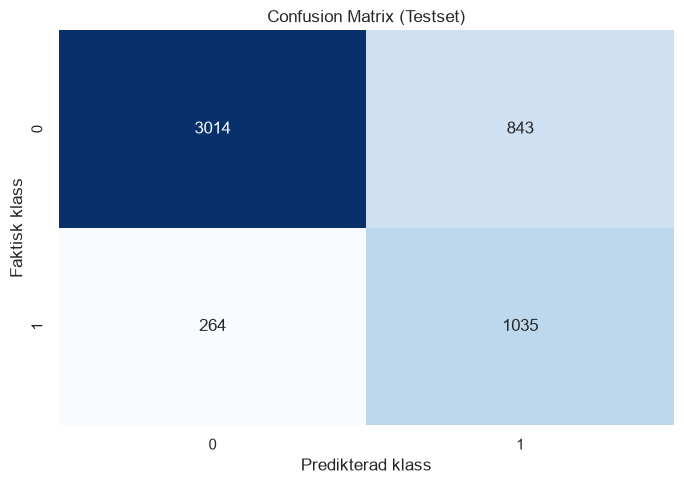

In [45]:
# Visualization – Confusion Matrix

y_pred_test = best_model.predict(X_test_scaled)

cm = confusion_matrix(
y_test,
y_pred_test
)

plt.figure(figsize=(7, 5))

sns.heatmap(
cm,
annot=True,
fmt="d",
cmap="Blues",
cbar=False
)

plt.title("Confusion Matrix (Testset)")
plt.xlabel("Predikterad klass")
plt.ylabel("Faktisk klass")

plt.tight_layout()
plt.show()

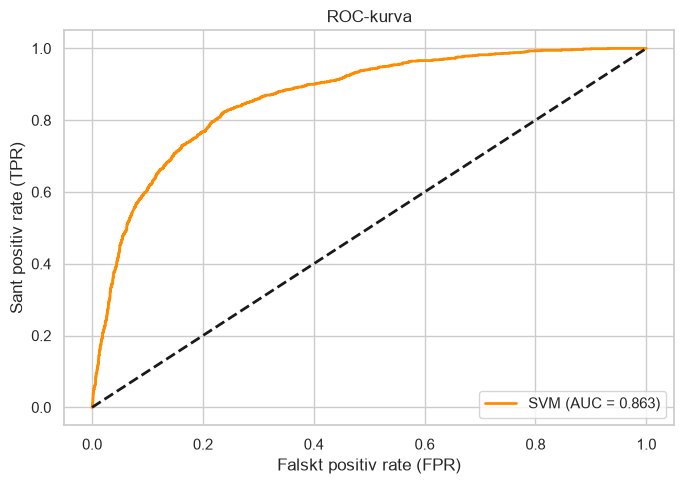

In [46]:
# Visualization – ROC Curve

y_prob_test = best_model.predict_proba(
X_test_scaled
)[:, 1]

fpr, tpr, thresholds = roc_curve(
y_test,
y_prob_test
)

auc_val = roc_auc_score(
y_test,
y_prob_test
)

plt.figure(figsize=(7, 5))

plt.plot(
fpr,
tpr,
label=f"SVM (AUC = {auc_val:.3f})",
color="darkorange",
lw=2
)

plt.plot(
[0, 1],
[0, 1],
"k--",
lw=2
)

plt.title("ROC-kurva")
plt.xlabel("Falskt positiv rate (FPR)")
plt.ylabel("Sant positiv rate (TPR)")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [47]:
# Business simulation on test set

df_test_eval = df_processed.loc[X_test.index].copy()

df_test_eval["predicted_optimal"] = y_pred_test

In [48]:
# 1. Average price selected by the model

model_avg_price = (
df_test_eval[
df_test_eval["predicted_optimal"] == 1
]["spot_price_eur_mwh"]
.mean()
)

In [49]:
# 2. Average price for actual optimal hours

actual_best_avg_price = (
df_test_eval[
df_test_eval["optimal_timme"] == 1
]["spot_price_eur_mwh"]
.mean()
)

In [50]:
# 3. Average price across the complete test set

total_avg_price = (
df_test_eval["spot_price_eur_mwh"]
.mean()
)

In [51]:
# 4. Average price for non-optimal hours
worst_avg_price = (
df_test_eval[
df_test_eval["optimal_timme"] == 0
]["spot_price_eur_mwh"]
.mean()
)

print("--- Affärsmässig Prissimulering (Testset) ---")

print(
f"Modellens utvalda snittpris: "
f"{model_avg_price:.2f} EUR/MWh"
)

print(
f"Teoretiskt bästa snittpris: "
f"{actual_best_avg_price:.2f} EUR/MWh"
)

print(
f"Totala testsetets snittpris: "
f"{total_avg_price:.2f} EUR/MWh"
)

print(
f"Snittpris för icke-optimala timmar: "
f"{worst_avg_price:.2f} EUR/MWh"
)

print(
f"\nModellen sparar ca "
f"{total_avg_price - model_avg_price:.2f} EUR/MWh "
f"i snitt jämfört med att inte optimera alls!"
)


--- Affärsmässig Prissimulering (Testset) ---
Modellens utvalda snittpris: 18.91 EUR/MWh
Teoretiskt bästa snittpris: 14.42 EUR/MWh
Totala testsetets snittpris: 35.21 EUR/MWh
Snittpris för icke-optimala timmar: 42.21 EUR/MWh

Modellen sparar ca 16.30 EUR/MWh i snitt jämfört med att inte optimera alls!


In [52]:
# Save trained model, scaler and feature columns

models_dir = Path("../models_bin")
models_dir.mkdir(exist_ok=True)

In [53]:
# Save SVM model

joblib.dump(
best_model,
models_dir / "svm_optimal_classifier.joblib"
)

['..\\models_bin\\svm_optimal_classifier.joblib']

In [54]:
# Save scaler

joblib.dump(
scaler,
models_dir / "scaler.joblib"
)

['..\\models_bin\\scaler.joblib']

In [56]:
# Save feature columns

with open(
    models_dir / "feature_cols.json",
    "w"
) as f:
    json.dump(
        feature_cols,
        f,
        indent=4
    )

print("\nModell, scaler och feature columns har sparats i:")
print(models_dir)


Modell, scaler och feature columns har sparats i:
..\models_bin
